In [2]:
# Load standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, propagation, simulator
from tudatpy import constants
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime
from tudatpy.astro import element_conversion
# For the minor planets
from tudatpy.data import horizons

# Additional import
import os           # for the extraction of asteroid kernels

from matplotlib.animation import FuncAnimation # For the animation
from IPython.display import HTML
from mpl_toolkits.mplot3d import Axes3D


# Step 1: Setup Conditions/ Basic Conditions

# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs (total simulation time of 5 years)
# Start dat = 25th of April 2004 (arbitrary choice)
# Tudat works in J2000, so use seconds
simulation_start_epoch = DateTime(2000, 1, 1).to_epoch() - 12 * 3600
simulation_end_epoch = DateTime(2010, 1, 3).to_epoch() - 12 * 3600
# simulation_end_epoch   = simulation_start_epoch + 10 * constants.JULIAN_YEAR


# Step 2: Define bodies in simulation

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create = [
    "Sun",
    # "Earth",
    # "Mercury",
    # "Venus",
    # "Mars",
    # "Jupiter",
    # "Saturn",
    # "Uranus",
    # "Neptune"
]

# The 21 smaller bodies do not exist inside of SPICE and therefore their mu has to be manually added
# Create a dictionary to store the names, ID numbers and mu (GM in km3/s2) of the asteroids 

# Will check later if I need to add e.g. radius, radiation or time of orbit around the Sun etc.

smaller_bodies = {
    "Ceres": [1, 62.10], 
    "Pallas": [2, 13.73],
    "Juno": [3, 1.61],
    "Vesta": [4, 17.38],
    "Hebe": [6, 0.89],
    "Iris": [7, 0.73],
    "Flora": [8, 0.27],
    "Metis": [9, 0.44],
    "Hygiea": [10, 5.97],
    "Irene": [14, 0.25],
    "Eunomia": [15, 1.88],
    "Psyche": [16, 1.65],
    "Fortuna": [19, 0.42],
    "Thalia": [23, 0.15],
    "Amphitrite": [29, 0.98],
    "Daphne": [41, 0.56],
    "Europa": [52, 1.48],
    "Bamberga": [324, 0.71],
    "Davida": [511, 1.14],
    "Herculina": [532, 0.66],
    "Interamnia": [704, 2.65]
}



In [3]:
# Many of the asteroids do not exist in the SPICE kernel
# Therefore I'm now adding them by downloading them in SPK files from the JPL Horizon website
# Then I will extract them with load_kernel

# ---------------------------------------------------------
# The path to the folder where the .bsp files are located
kernel_directory = "/home/emmabob/Bachelor_Project/asteroid_kernels/" 

# Loop through the dictionary and load the corresponding .bsp file
for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
    
    # Calculate the NAIF ID from the data list
    # E.g. Juno has 20000003 (ID: 3)
    ast_id = data[0]
    naif_id = 20000000 + ast_id
    
    # Then extract the ephemeris for each asteroid
    kernel_path = os.path.join(kernel_directory, f"{naif_id}.bsp")
    if os.path.exists(kernel_path):
        spice.load_kernel(kernel_path)
        print(f"{i}.Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
    else:
        print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")


1.Successfully loaded the kernel for Ceres using file: 20000001.bsp
2.Successfully loaded the kernel for Pallas using file: 20000002.bsp
3.Successfully loaded the kernel for Juno using file: 20000003.bsp
4.Successfully loaded the kernel for Vesta using file: 20000004.bsp
5.Successfully loaded the kernel for Hebe using file: 20000006.bsp
6.Successfully loaded the kernel for Iris using file: 20000007.bsp
7.Successfully loaded the kernel for Flora using file: 20000008.bsp
8.Successfully loaded the kernel for Metis using file: 20000009.bsp
9.Successfully loaded the kernel for Hygiea using file: 20000010.bsp
10.Successfully loaded the kernel for Irene using file: 20000014.bsp
11.Successfully loaded the kernel for Eunomia using file: 20000015.bsp
12.Successfully loaded the kernel for Psyche using file: 20000016.bsp
13.Successfully loaded the kernel for Fortuna using file: 20000019.bsp
14.Successfully loaded the kernel for Thalia using file: 20000023.bsp
15.Successfully loaded the kernel for 

In [4]:
# Extract only the asteroids' names 
# This is so that the list of all bodies can be created
smaller_bodies_list = list(smaller_bodies.keys())

# Manually add 1998 TU3
asteroid_name = "1998-TU3"


# Combine all bodies into one large list
bodies_to_create = larger_bodies_to_create + smaller_bodies_list + [asteroid_name]
# bodies_to_propagate = ["1998-TU3"]     # I only propagate TU3, I pull the other values from pre-existing ephemeris

# ----------------------------
# Create bodies in simulation.

# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'SSB',              # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'ECLIPJ2000')       # Intiial conditions from JPL are in J2000

# To avoid the issue of calling for coordinates that don't exist in the ephermeris
# Add a buffer time

buffer_time = 5 * constants.JULIAN_DAY

# A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon

for i, (name, data) in enumerate(smaller_bodies.items(), start=1):

    # Extract asteroid properties
    ast_id = data[0]
    ast_mu = data[1] * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units)

    # Calculate the SPICE NAIF ID (2000000 + minor planet number) again
    naif_id = 20000000 + ast_id

    try:
        
        # To fix Tudat finding the data:

        # This solves the "Object has no attribute naif_id" error by 
        # linking the name and ID in the global SPICE map.
        # spice.set_id_to_name_mapping(naif_id, name)

        naif_id_str = str(20000000 + ast_id)

        # --------------------------------------------
        # Extracting the ephemeris from JPL Horizons (not SPICE)

        # ephemeris_settings_ast = environment_setup.ephemeris.jpl_horizons(
        #     horizons_query = str(ast_id),
        #     horizons_location = "@0",       # This sets the center at the SSB (an exact command)
        #     frame_origin = "SSB",
        #     frame_orientation = "ECLIPJ2000",    # Debate between ECLIPJ2000 and J2000
        #     epoch_start = simulation_start_epoch - buffer_time,
        #     epoch_end = simulation_end_epoch + buffer_time,
        #     epoch_step = "1d",              # 1 day step
        #     extended_query = True           # Helps Horizon resolve asteroids' IDs more robustly
        # )


        # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
        DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
            frame_origin = 'Sun',               # The SPK files were w.r.t the Sun
            frame_orientation = 'ECLIPJ2000',        # tells Tudat the asteroids' coordinates are wrt ECLIPJ2000 
            body_name_to_use = naif_id_str)


        # Create empty slots, then insert the asteroids
        body_settings.add_empty_settings(name)
        # Assign ephemeris
        body_settings.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast

        # # Know that Tudat will be looking for names of the asteroids, while they're named after their ID's
        # # Thus, link the name to the specific NAIF ID loaded in the .bsp file
        # body_settings.get(name).ephemeris_settings.make_multi_arc_ephemeris = False # so that Tudat won't try to string together things
        # body_settings.get(name).ephemeris_settings.naif_id = str(naif_id)           # getting the info from the naif_id and not the name :)


        # Assign gravity field (w. the central function that manually adds the mu)
        body_settings.get(name).gravity_field_settings = (
            environment_setup.gravity_field.central(ast_mu)
        )

        print(f" {i}. Successfully configured {name} (ID: {ast_id} / NAIF: {naif_id})")

    except Exception as e:
        print(f"Could not fetch data for {name}: {e}")


# Manually add empty settings for TU3
body_settings.add_empty_settings(asteroid_name)

# Thus, the environment becomes:
body_system = environment_setup.create_system_of_bodies(body_settings)


 1. Successfully configured Ceres (ID: 1 / NAIF: 20000001)
 2. Successfully configured Pallas (ID: 2 / NAIF: 20000002)
 3. Successfully configured Juno (ID: 3 / NAIF: 20000003)
 4. Successfully configured Vesta (ID: 4 / NAIF: 20000004)
 5. Successfully configured Hebe (ID: 6 / NAIF: 20000006)
 6. Successfully configured Iris (ID: 7 / NAIF: 20000007)
 7. Successfully configured Flora (ID: 8 / NAIF: 20000008)
 8. Successfully configured Metis (ID: 9 / NAIF: 20000009)
 9. Successfully configured Hygiea (ID: 10 / NAIF: 20000010)
 10. Successfully configured Irene (ID: 14 / NAIF: 20000014)
 11. Successfully configured Eunomia (ID: 15 / NAIF: 20000015)
 12. Successfully configured Psyche (ID: 16 / NAIF: 20000016)
 13. Successfully configured Fortuna (ID: 19 / NAIF: 20000019)
 14. Successfully configured Thalia (ID: 23 / NAIF: 20000023)
 15. Successfully configured Amphitrite (ID: 29 / NAIF: 20000029)
 16. Successfully configured Daphne (ID: 41 / NAIF: 20000041)
 17. Successfully configured E

In [5]:
for asteroid in smaller_bodies_list:
    print(
        asteroid,
        f"{body_system.get(asteroid).gravitational_parameter:.3e}"
    )

Ceres 6.210e+10
Pallas 1.373e+10
Juno 1.610e+09
Vesta 1.738e+10
Hebe 8.900e+08
Iris 7.300e+08
Flora 2.700e+08
Metis 4.400e+08
Hygiea 5.970e+09
Irene 2.500e+08
Eunomia 1.880e+09
Psyche 1.650e+09
Fortuna 4.200e+08
Thalia 1.500e+08
Amphitrite 9.800e+08
Daphne 5.600e+08
Europa 1.480e+09
Bamberga 7.100e+08
Davida 1.140e+09
Herculina 6.600e+08
Interamnia 2.650e+09


In [6]:
for asteroid_test in ["Ceres", "Vesta", "Juno", "Pallas", "Hebe"]:
    state_test = body_system.get(asteroid).ephemeris.cartesian_state(
        simulation_start_epoch
    )

    print(
        asteroid_test,
        np.linalg.norm(state_test[:3])/constants.ASTRONOMICAL_UNIT
    )

Ceres 3.3170208773919825
Vesta 3.3170208773919825
Juno 3.3170208773919825
Pallas 3.3170208773919825
Hebe 3.3170208773919825


In [7]:
print(name, naif_id, naif_id_str)

Interamnia 20000704 20000704


In [8]:
# Step 3: Create the Propagation Setup

bodies_to_propagate = ["1998-TU3"]

central_bodies = ["Sun"]

In [9]:
# Step 4: Define the accelerations acting on TU3 (for now)

# The planets
accelerations_planets = {
    "Sun": [
        propagation_setup.acceleration.point_mass_gravity(),
        # propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # propagation_setup.acceleration.yarkovsky(-2.65*10**(-14)),                      # The Yarkovsky parameter (Supposed to be added to the asteroid in the code?)
        # propagation_setup.acceleration.spherical_harmonic()                           # The solar quadrupole moment

    ],
    # "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    # "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    # "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    # "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    # "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    # "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    # "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    # "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

# The asteroids

accelerations_asteroids = {
    
    asteroid_name: [
        propagation_setup.acceleration.point_mass_gravity()
    ]
    for asteroid_name in smaller_bodies_list
}


# Merge dictionaries
accelerations_merged = (
    accelerations_planets |
    accelerations_asteroids
)

# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict = {
    "1998-TU3": accelerations_merged
}



# Step 5: Define the Initial States of Each Body
# This is where we mix SPICE data (for the planets) with Keplerian data (the asteroid)

sun_gravitational_parameter = body_system.get("Sun").gravitational_parameter

# Grabbing the initial state at 2000-01-01 from JPL with cartesian_to_keplarian() (in astro)

# Cartesian state vector
cartesian_elements = np.array([
    [4.543863572576185E+07 * 1e3],   # X  [m]
    [-9.673019712424231E+07 * 1e3],  # Y  [m]
    [-2.313075952057116E+06 * 1e3],  # Z  [m]
    [3.661410298575712E+01 * 1e3],   # VX [m/s]
    [-1.757686929389374E+00 * 1e3],  # VY [m/s]
    [-3.350242409196601E+00 * 1e3]   # VZ [m/s]
], dtype=np.float64)


test_initial_TU3_array = element_conversion.cartesian_to_keplerian(
    cartesian_elements = cartesian_elements,
    gravitational_parameter = sun_gravitational_parameter
    )

print("Keplerian Elements:")
print(test_initial_TU3_array)
print(test_initial_TU3_array[0])
print(test_initial_TU3_array[2])

    # ---------------------------------
    # New initial condition

initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
    gravitational_parameter = sun_gravitational_parameter,
    semi_major_axis = test_initial_TU3_array[0],                 #meters
    eccentricity = test_initial_TU3_array[1],                    #unitless
    inclination = test_initial_TU3_array[2],                     # cartesian_to_keplerian returns angles in radians
    argument_of_periapsis = test_initial_TU3_array[3],
    longitude_of_ascending_node = test_initial_TU3_array[4],
    true_anomaly = test_initial_TU3_array[5],                
)



system_initial_state = initial_state_TU3


# Step 6: Create the conditions for propagation:

# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch) 

# Create numerical integrator settings
fixed_step_size = 24 * 3600.0    # each hour
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, 
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78     # Range-Kutta 78 instead of 4 (more precise as I do 1 hour steps for many years)
)


# Create the acceleration model
acceleration_models = (
    propagation_setup.create_acceleration_models(
        body_system,
        acceleration_dict,
        bodies_to_propagate,
        central_bodies
    )
)



# Propagating TU3 with the created system
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)



# Create simulation object and propagate the dynamics
dynamics_simulator = simulator.create_dynamics_simulator(
    body_system, propagator_settings
)

# Extract the resulting state history and convert it to an ndarray
states_TU3 = dynamics_simulator.propagation_results.state_history
states_array_TU3 = result2array(states_TU3)



Keplerian Elements:
[1.17640978e+11 4.74911638e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.88703315e+00]
117640977822.613
0.09419482774380611


In [10]:
# Creating the same model without the asteroids

body_settings_no_21asteroids = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'SSB',                   # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'ECLIPJ2000')       # Intiial conditions from JPL are in J2000

# Manually add empty settings for TU3
body_settings_no_21asteroids.add_empty_settings(asteroid_name)

# Thus, the environment becomes:
body_system_no_21asteroids = environment_setup.create_system_of_bodies(body_settings_no_21asteroids)


# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict_no_21asteroids = {
    "1998-TU3": accelerations_planets
}

# Create the acceleration model
acceleration_models_no_21asteroids = (
    propagation_setup.create_acceleration_models(
        body_system_no_21asteroids,
        acceleration_dict_no_21asteroids,
        bodies_to_propagate,
        central_bodies
    )
)


# Propagating TU3 with the created system
propagator_settings_no_21asteroids = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models_no_21asteroids,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

# Create simulation object and propagate the dynamics
dynamics_simulator_no_21asteroids = simulator.create_dynamics_simulator(
    body_system_no_21asteroids, propagator_settings_no_21asteroids
)

# Extract the resulting state history and convert it to an ndarray
states_TU3_no_21asteroids = dynamics_simulator_no_21asteroids.propagation_results.state_history
states_array_TU3_no_21asteroids = result2array(states_TU3_no_21asteroids)

In [11]:
# Extract the times when there's 21 asteroids
times = states_array_TU3[:,0]

# Extract the times when there are NO 21 asteroids
times_no_21asteroids = states_array_TU3_no_21asteroids[:,0]

print(
    f"""
Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: \n{
    states_TU3[simulation_start_epoch][:3] / 1E3}
The initial velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_start_epoch][3:] / 1E3}
\nAfter {simulation_end_epoch} seconds the position vector of TU3 is [km]: \n{
    states_TU3[simulation_end_epoch][:3] / 1E3}
And the velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_end_epoch][3:] / 1E3}
    """
)

print(
    f"""
Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 WITHOUT ASTEROIDS is [km]: \n{
    states_TU3_no_21asteroids[simulation_start_epoch][:3] / 1E3}
The initial velocity vector of TU3 WITHOUT ASTEROIDS is [km/s]: \n{
    states_TU3_no_21asteroids[simulation_start_epoch][3:] / 1E3}
\nAfter {simulation_end_epoch} seconds the position vector of TU3 WITHOUT ASTEROIDS is [km]: \n{
    states_TU3_no_21asteroids[simulation_end_epoch][:3] / 1E3}
And the velocity vector of TU3 WITHOUT ASTEROIDS is [km/s]: \n{
    states_TU3_no_21asteroids[simulation_end_epoch][3:] / 1E3}
    """
)

# Extract the 21 asteroids:
# Also to check what the heck the asteroids' coordinates look like:

asteroid_ephemerides = {}

for asteroid_name in smaller_bodies_list:

    asteroid_states = np.array([

        body_system.get(asteroid_name)
        .ephemeris
        .cartesian_state(time)

        for time in times

    ])

    asteroid_ephemerides[asteroid_name] = asteroid_states



Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: 
[ 45438635.72576186 -96730197.12424232  -2313075.95205713]
The initial velocity vector of TU3 is [km/s]: 
[36.61410299 -1.75768693 -3.35024241]

After 315748800.0 seconds the position vector of TU3 is [km]: 
[ 1.71694120e+08  1.89208360e+07 -1.62402014e+07]
And the velocity vector of TU3 is [km/s]: 
[-1.96643486 19.94602905 -0.20736846]
    

Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 WITHOUT ASTEROIDS is [km]: 
[ 45438635.72576186 -96730197.12424232  -2313075.95205713]
The initial velocity vector of TU3 WITHOUT ASTEROIDS is [km/s]: 
[36.61410299 -1.75768693 -3.35024241]

After 315748800.0 seconds the position vector of TU3 WITHOUT ASTEROIDS is [km]: 
[ 1.71694120e+08  1.89208361e+07 -1.62402015e+07]
And the velocity vector of TU3 WITHOUT ASTEROIDS is [km/s]: 
[-1.96643491 19.94602904 -0.20736845]
    


In [12]:
# Difference:
# Testing what the distance difference is after 10 years in meters

diff_r_TU3_21_asteroids_endepoch = (
    states_TU3[simulation_end_epoch][:3]
    - states_TU3_no_21asteroids[simulation_end_epoch][:3]
)

# Position differences
diff_xyz_21asteroids = (
    states_array_TU3[:,1:4]
    - states_array_TU3_no_21asteroids[:,1:4]
)

# Extract components
diff_x = diff_xyz_21asteroids[:,0]
diff_y = diff_xyz_21asteroids[:,1]
diff_z = diff_xyz_21asteroids[:,2]

print(f"The difference in position with and without asteroids at index 0: {diff_xyz_21asteroids[3]}")
print(f"The difference with and without asteroids at the end-epoch is: {diff_r_TU3_21_asteroids_endepoch}")

The difference in position with and without asteroids at index 0: [ 0.00349426 -0.00086975  0.00046253]
The difference with and without asteroids at the end-epoch is: [  8.54272461 -75.81645203   7.22673988]


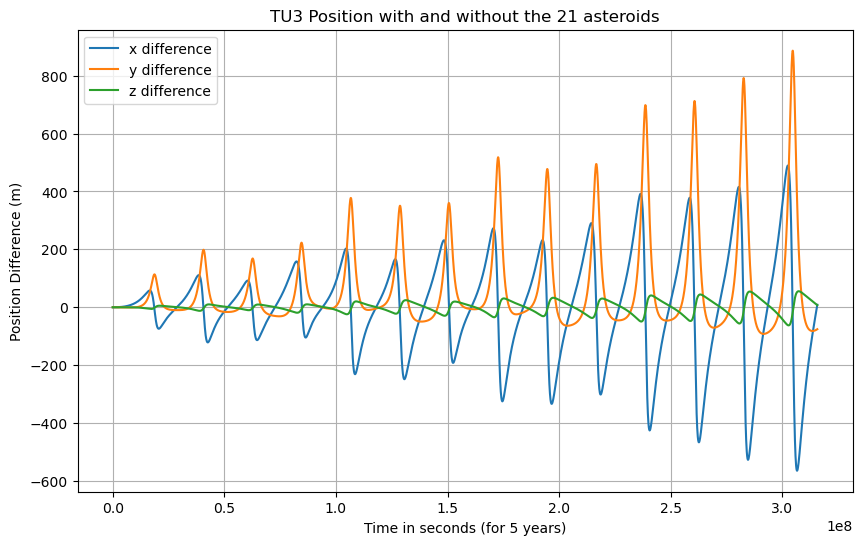

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(times_no_21asteroids, diff_x, label='x difference')
plt.plot(times_no_21asteroids, diff_y, label='y difference')
plt.plot(times_no_21asteroids, diff_z, label='z difference')

plt.xlabel('Time in seconds (for 5 years)')
plt.ylabel('Position Difference (m)')
plt.title('TU3 Position with and without the 21 asteroids')

plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Verifying that the right semi-major axes are being grabbed

for asteroid_test in ["Ceres", "Vesta", "Juno", "Pallas", "Hebe"]:
    state_test = body_system.get(asteroid_test).ephemeris.cartesian_state(
        simulation_start_epoch
    )

    print(
        asteroid_test,
        np.linalg.norm(state_test[:3])/constants.ASTRONOMICAL_UNIT
    )

Ceres 2.5511003765494022
Vesta 2.163006550420055
Juno 3.120566354621365
Pallas 2.1439817513371255
Hebe 2.1471072401784204


In [15]:
print(
    body_system.get("Ceres")
    .ephemeris
    .cartesian_state(simulation_start_epoch)
)

[-3.55673469e+11  1.19794569e+11  6.92395214e+10 -6.24263297e+03
 -1.83167934e+04  5.85196128e+02]


In [16]:
print(asteroid_ephemerides["Ceres"][-1])
print(asteroid_ephemerides["Ceres"][1])
# print(asteroid_ephemerides["Ceres"][100])

# The planets are extracted similarly when plotting the Solar System

[-2.45535012e+11 -3.20197396e+11  3.52598035e+10  1.32760405e+04
 -1.22594033e+04 -2.82880456e+03]
[-3.56209662e+11  1.18210935e+11  6.92894652e+10 -6.16921469e+03
 -1.83413504e+04  5.70907992e+02]


From JPL Horizon:

2451542.500000000 = A.D. 1999-Dec-30 00:00:00.0000 TDB 
 X =-3.556517907686765E+08 Y = 1.225399001636502E+08 Z = 6.916682933312005E+07
 VX=-6.379884035034717E+00 VY=-1.827955127439522E+01 VZ= 6.135834306760044E-01

2451542.541666667 = A.D. 1999-Dec-30 01:00:00.0000 TDB 
 X =-3.556747528630831E+08 Y = 1.224740918769759E+08 Z = 6.916903716350484E+07
 VX=-6.376835048995869E+00 VY=-1.828060789378443E+01 VZ= 6.129890025689253E-01

2451542.583333333 = A.D. 1999-Dec-30 02:00:00.0000 TDB 
 X =-3.556977039808095E+08 Y = 1.224082797874983E+08 Z = 6.917124285391915E+07
 VX=-6.373785879373899E+00 VY=-1.828166394289597E+01 VZ= 6.123945582213590E-01


2451544.000000000 = A.D. 1999-Dec-31 12:00:00.0000 TDB 
 X =-3.564715061665204E+08 Y = 1.201684207435758E+08 Z = 6.924496263329709E+07
 VX=-6.270005724096723E+00 VY=-1.831723004860454E+01 VZ= 5.921739505115786E-01

2451544.500000000 = A.D. 2000-Jan-01 00:00:00.0000 TDB 
 X =-3.567415782604432E+08 Y = 1.193768483753399E+08 Z = 6.927039031044589E+07
 VX=-6.233327667894319E+00 VY=-1.832962513060474E+01 VZ= 5.850329576204985E-01

In [17]:
import pandas as pd

# Load CSV
# Know that the steps is 1 day (not 1 hour)
csv_data = pd.read_csv("/home/emmabob/Bachelor_Project/Planet_Effects/Ceres_JPL_vectors_10yrs_1day.csv")
# csv_data = pd.read_csv("/home/emmabob/Bachelor_Project/TU3/2025_Nov_21_JPL_vectors.csv")

# Convert columns to arrays
x_JPL_Ceres = csv_data["x"].to_numpy() * 1e3  # km to m
y_JPL_Ceres = csv_data["y"].to_numpy() * 1e3
z_JPL_Ceres = csv_data["z"].to_numpy() * 1e3

vx_JPL_Ceres = csv_data["vx"].to_numpy() * 1e3    # km/s to m/s
vy_JPL_Ceres = csv_data["vy"].to_numpy() * 1e3
vz_JPL_Ceres = csv_data["vz"].to_numpy() * 1e3

In [18]:
# Trying with HorizonsQuery instead:

from tudatpy.data.horizons import HorizonsQuery

obj = HorizonsQuery(
    query_id="1;",
    location="@0",  # SSB
    epoch_start = simulation_start_epoch,
    epoch_end = simulation_end_epoch,
    epoch_step = "24h",
    extended_query = True,
)

initial_states_horizon = obj.cartesian(frame_orientation='J2000',
            aberations='geometric')

states_horizonsq = initial_states_horizon[:, 1:]    # unpack and remvoe the first component (that is time)

In [21]:
# To plot the difference begin by combining the JPL Horizon data:

states_JPL_Ceres = np.column_stack((
    x_JPL_Ceres,
    y_JPL_Ceres,
    z_JPL_Ceres,
    vx_JPL_Ceres,
    vy_JPL_Ceres,
    vz_JPL_Ceres
))

# The combine the data for Ceres (extracted from SPK) in a similar way
states_SPK_Ceres = np.array([body_system.get("Ceres")
    .ephemeris
    .cartesian_state(t)
    for t in times
])
# Remember that: times = states_array_TU3[:,0] (1 step = 1 day)

print(states_SPK_Ceres.shape)
print(states_JPL_Ceres.shape)
print(states_horizonsq.shape)

x_SPK_Ceres  = states_SPK_Ceres[:, 0]
y_SPK_Ceres  = states_SPK_Ceres[:, 1]
z_SPK_Ceres  = states_SPK_Ceres[:, 2]

vx_SPK_Ceres = states_SPK_Ceres[:, 3]
vy_SPK_Ceres = states_SPK_Ceres[:, 4]
vz_SPK_Ceres = states_SPK_Ceres[:, 5]

# If I need to plot the total difference, but I want to plot the orbits later as well
# diff_SPK_vs_JPL = states_SPK_Ceres - states_JPL_Ceres

# # Finding the difference
# diff_x = x_JPL_Ceres - x_SPK_Ceres
# diff_y = y_JPL_Ceres - y_SPK_Ceres
# diff_z = z_JPL_Ceres - z_SPK_Ceres

# diff_vx = vx_JPL_Ceres - vx_SPK_Ceres
# diff_vy = vy_JPL_Ceres - vy_SPK_Ceres
# diff_vz = vz_JPL_Ceres - vz_SPK_Ceres

# For testing HorizonsQuery

x_HorizonsQ_Ceres  = states_horizonsq[:, 0]
y_HorizonsQ_Ceres  = states_horizonsq[:, 1]
z_HorizonsQ_Ceres  = states_horizonsq[:, 2]

vx_HorizonsQ_Ceres = states_horizonsq[:, 3]
vy_HorizonsQ_Ceres = states_horizonsq[:, 4]
vz_HorizonsQ_Ceres = states_horizonsq[:, 5]

# Finding the difference
diff_x = x_HorizonsQ_Ceres - x_SPK_Ceres
diff_y = y_HorizonsQ_Ceres - y_SPK_Ceres
diff_z = z_HorizonsQ_Ceres - z_SPK_Ceres

diff_vx = vx_HorizonsQ_Ceres- vx_SPK_Ceres
diff_vy = vy_HorizonsQ_Ceres - vy_SPK_Ceres
diff_vz = vz_HorizonsQ_Ceres - vz_SPK_Ceres

(3656, 6)
(3659, 6)
(3656, 6)


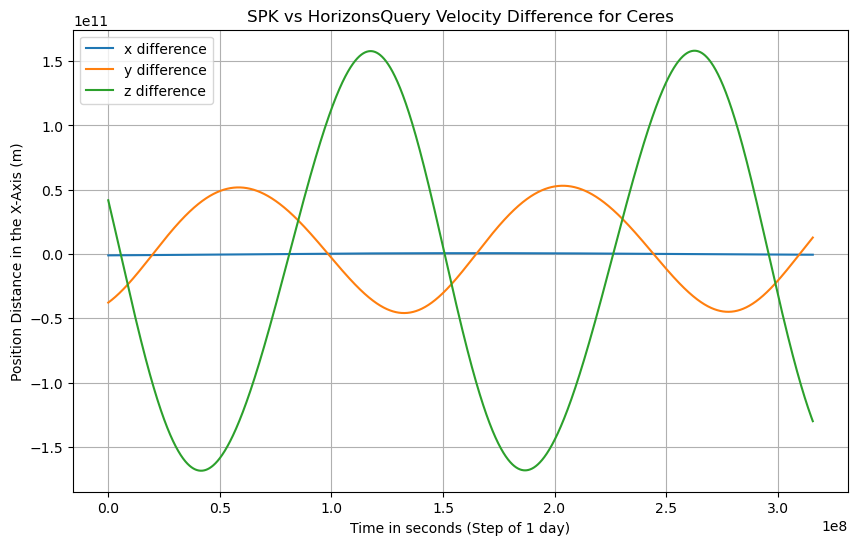

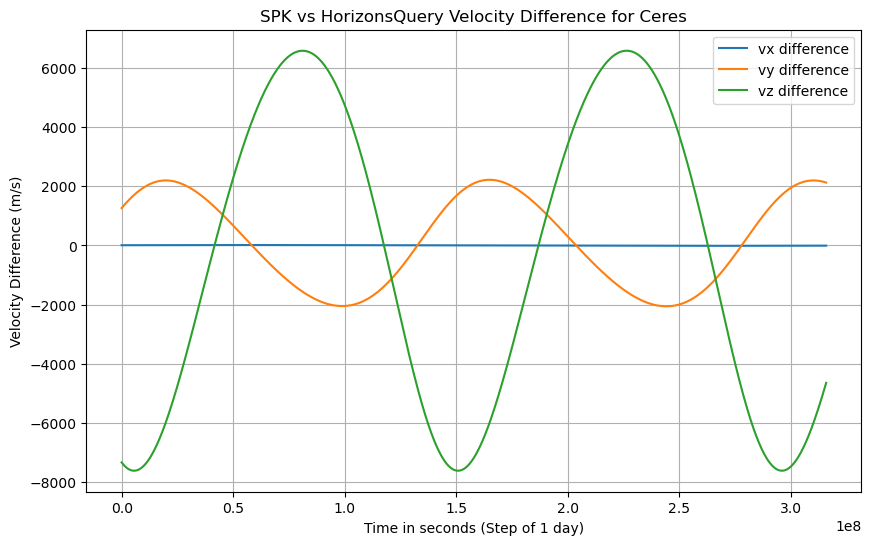

In [25]:
# =========================
# POSITION DIFFERENCES
# =========================

plt.figure(figsize=(10, 6))

plt.plot(times, diff_x, label='x difference')
plt.plot(times, diff_y, label='y difference')
plt.plot(times, diff_z, label='z difference')

# plt.plot(times, x_SPK_Ceres, label='SPK Ceres x-position', color='red')
# plt.plot(times, x_JPL_Ceres, label='JPL Ceres x-position', color='yellow')
# plt.plot(t_TU3_days, x_TU3, label='z difference', color='red')        # Tudat x-position
# plt.plot(t_TU3_days, x_JPL, label='z difference', color='yellow')     # JPL x-position

plt.xlabel('Time in seconds (Step of 1 day)')
plt.ylabel('Position Distance in the X-Axis (m)')
plt.title('SPK vs HorizonsQuery Velocity Difference for Ceres')

plt.legend()
plt.grid(True)

plt.show()


# =========================
# VELOCITY DIFFERENCES
# =========================

plt.figure(figsize=(10, 6))

plt.plot(times, diff_vx, label='vx difference')
plt.plot(times, diff_vy, label='vy difference')
plt.plot(times, diff_vz, label='vz difference')

plt.xlabel('Time in seconds (Step of 1 day)')
plt.ylabel('Velocity Difference (m/s)')
plt.title('SPK vs HorizonsQuery Velocity Difference for Ceres')

plt.legend()
plt.grid(True)

plt.show()

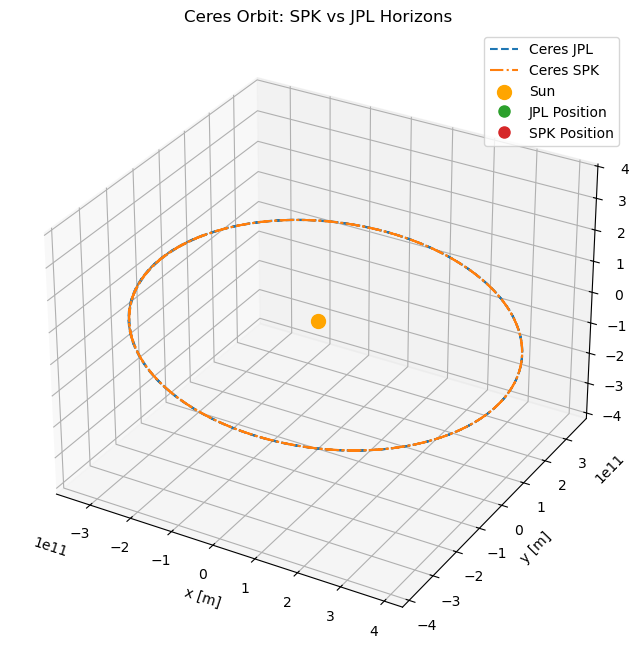

In [89]:
# Create figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot complete trajectories
ax.plot(
    x_JPL_Ceres,
    y_JPL_Ceres,
    z_JPL_Ceres,
    '--',
    label='Ceres JPL'
)

ax.plot(
    x_SPK_Ceres,
    y_SPK_Ceres,
    z_SPK_Ceres,
    '-.',
    label='Ceres SPK'
)

# Sun
ax.scatter(
    0,
    0,
    0,
    s=100,
    color='orange',
    label='Sun'
)

# Animated points
point_JPL, = ax.plot(
    [],
    [],
    [],
    'o',
    markersize=8,
    label='JPL Position'
)

point_SPK, = ax.plot(
    [],
    [],
    [],
    'o',
    markersize=8,
    label='SPK Position'
)

# Labels
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_title('Ceres Orbit: SPK vs JPL Horizons')

# Equal-ish scaling
max_range = np.array([
    x_SPK_Ceres.max() - x_SPK_Ceres.min(),
    y_SPK_Ceres.max() - y_SPK_Ceres.min(),
    z_SPK_Ceres.max() - z_SPK_Ceres.min()
]).max() / 2

mid_x = (x_SPK_Ceres.max() + x_SPK_Ceres.min()) / 2
mid_y = (y_SPK_Ceres.max() + y_SPK_Ceres.min()) / 2
mid_z = (z_SPK_Ceres.max() + z_SPK_Ceres.min()) / 2

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.legend()

def init():
    point_JPL.set_data([], [])
    point_JPL.set_3d_properties([])

    point_SPK.set_data([], [])
    point_SPK.set_3d_properties([])

    return point_JPL, point_SPK

def update(frame):

    point_JPL.set_data(
        [x_JPL_Ceres[frame]],
        [y_JPL_Ceres[frame]]
    )
    point_JPL.set_3d_properties(
        [z_JPL_Ceres[frame]]
    )

    point_SPK.set_data(
        [x_SPK_Ceres[frame]],
        [y_SPK_Ceres[frame]]
    )
    point_SPK.set_3d_properties(
        [z_SPK_Ceres[frame]]
    )

    return point_JPL, point_SPK

ani = FuncAnimation(
    fig,
    update,
    frames=len(x_JPL_Ceres),
    init_func=init,
    interval=30,
    blit=False
)

# ani.save(
#     "/home/emmabob/Bachelor_Project/Photos_Folder/Animations/Ceres_orbit_test1_10years.mp4",
#     writer="ffmpeg",
#     fps=20,
#     dpi=150
# )

# HTML(ani.to_jshtml())

In [ ]:
from IPython.display import Video

Video("/home/emmabob/Bachelor_Project/Photos_Folder/Animations/Ceres_orbit_test1_10years.mp4")

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Solar System + 1998 TU3 for 5 years')

ax.scatter(0,0,0,s=100,label="Sun", color='orange')

ax.plot(
    states_array_TU3[:,1],
    states_array_TU3[:,2],
    states_array_TU3[:,3],
    label="1998-TU3",
    linestyle='-.'
)

# Define colors or a colormap for variety
planet_colours = ['silver', 'gold', 'teal', 'tab:red', 'darkorange', 'wheat', 'lightblue', 'royalblue']
planets_names = ["Mercury","Venus","Earth","Mars","Jupiter","Saturn","Uranus","Neptune"]

# Loop through the planets you created in Step 2
for i, planet_name in enumerate(planets_names):
    # Extract states from the ephemeris for the simulation times
    planet_states = np.array([
        body_system.get(planet_name).ephemeris.cartesian_state(time)
        for time in times
    ])
    
    # Plot x, y, z (Indices 0, 1, 2)
    ax.plot(
        planet_states[:, 0], 
        planet_states[:, 1], 
        planet_states[:, 2], 
        label = planet_name,
        color = planet_colours[i-1]
    )

for asteroid_name, asteroid_states in asteroid_ephemerides.items():

    ax.plot(
        asteroid_states[:,0],
        asteroid_states[:,1],
        asteroid_states[:,2],
        label=asteroid_name,
        linestyle='-.'
    )


ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

# # TU3 Orbit
# ax.set_xlim(-5e10, 5e10)
# ax.set_ylim(-5e10, 5e10)
# ax.set_zlim(-1e10, 1e10)

# # Around Jupiter Size
# ax.set_xlim(-5e11, 5e11)
# ax.set_ylim(-5e11, 5e11)
# ax.set_zlim(-5e11, 5e11)

# Limits for the whole Solar System
ax.set_xlim(-3e12, 3e12)
ax.set_ylim(-3e12, 3e12)
ax.set_zlim(-3e12, 3e12)

ax.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()